
## Рабочая тетрадь №2

## Задания:

### 1. Постройте линейную дискриминантную функцию $ g(x) = \omega^Tx + w_0 $, разделяющую 2 класса.

Веса омега [-1.09629684 -1.07718275]
Свободный член 1.0285194049069843


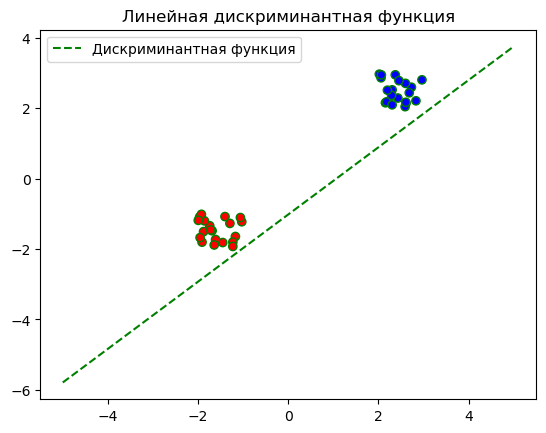

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression 



np.random.seed(42)

class_0 = np.random.rand(20 , 2) + [2,2]
class_1 = np.random.rand(20 , 2) + [-2,-2]


X = np.vstack([class_0 , class_1])
y = np.array([0] * 20 + [1] * 20)


model = LogisticRegression()
model.fit(X, y)


omega = model.coef_[0]
w0 = model.intercept_[0]

print(f'Веса омега {omega}')
print(f'Свободный член {w0}')
        

plt.scatter(X[:,0] , X[:,1] , c = y , cmap = 'bwr' , edgecolor = 'g')
x_range = np.linspace(-5,5,100)
y_range = -(omega[0] + x_range  * w0) / omega[1]



plt.plot(x_range , y_range , 'g--', label = "Дискриминантная функция") 
plt.legend()
plt.title("Линейная дискриминантная функция")
plt.show()

### 2. Постройте квадратичную дискриминантную функцию вида $ g(x) = x^TAx + w^Tx + w_0 $ для 2 классов.
​


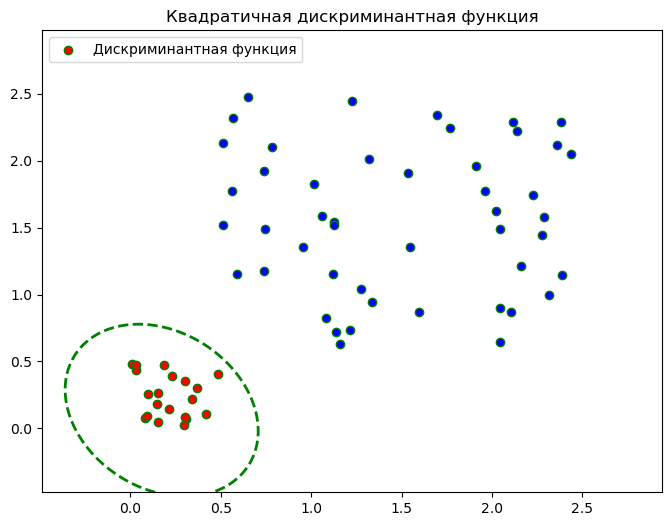

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

np.random.seed(42)

class_0 = np.random.rand(20, 2) * 0.5 
class_1 = np.random.rand(50, 2) * 2 + [0.5, 0.5] 
class_1 = class_1[np.linalg.norm(class_1, axis=1) > 1.2]

X = np.vstack([class_0, class_1])
y = np.array([0] * len(class_0) + [1] * len(class_1))

model = QuadraticDiscriminantAnalysis() 
model.fit(X, y)

plt.figure(figsize=(8, 6))

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))

Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0.5], colors='green', linestyles='--', linewidths=2)

plt.scatter(class_0[:, 0], class_0[:, 1], c='red', edgecolors='green', label='Класс 0')
plt.scatter(class_1[:, 0], class_1[:, 1], c='blue', edgecolors='green', label='Класс 1')

plt.title("Квадратичная дискриминантная функция")
plt.legend(["Дискриминантная функция"], loc='upper left')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(False)

plt.show()

### 3. Найдите параметры для n точек:
- Линейной модели, минимизируя MAE;
- Квадратичной модели, минимизируя MSE;
- Логистической модели, минимизируя log loss;
- Кубической модели, минимизируя MRSE.

Параметры моделей:
1. Линейная (MAE): w1=2.450, w0=-2.091
2. Квадратичная (MSE): w2=0.627, w1=-0.857, w0=0.897
3. Логистическая (Log Loss): w1=52.116, w0=-132.903
4. Кубическая (MRSE): w3=0.101, w2=-0.028, w1=0.225, w0=-0.124


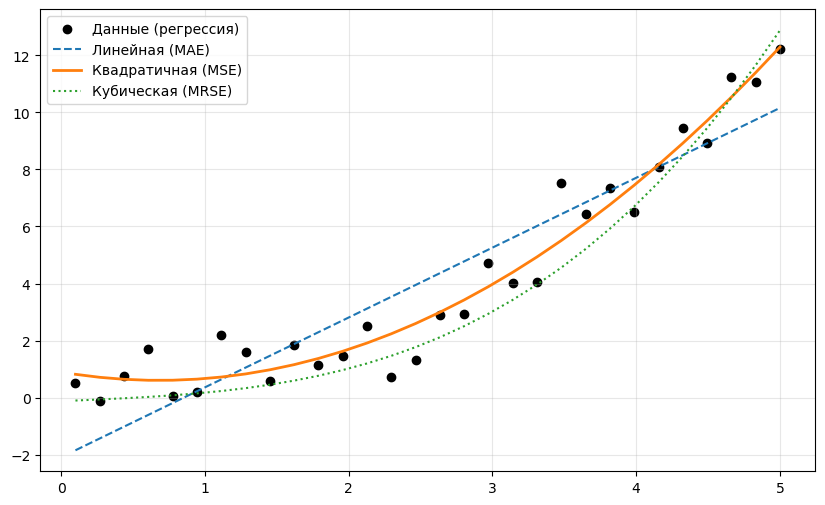

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression


np.random.seed(42)
n = 30
x = np.linspace(0.1, 5, n)

y_reg = 0.5 * x**2 + np.random.normal(0, 1, n)
y_clf = (x > 2.5).astype(int) 



def mae_loss(w, x, y):
    return np.mean(np.abs(y - (w[1] * x + w[0])))

def mrse_loss(w, x, y):
    y_pred = w[3]*x**3 + w[2]*x**2 + w[1]*x + w[0]
    return np.mean(((y - y_pred) / y)**2)




res_mae = minimize(mae_loss, x0=[0, 0], args=(x, y_reg))
w_mae = res_mae.x

w_mse = np.polyfit(x, y_reg, 2)


log_reg = LogisticRegression(penalty=None)
log_reg.fit(x.reshape(-1, 1), y_clf)
w_log = [log_reg.intercept_[0], log_reg.coef_[0][0]] # [w0, w1]


res_mrse = minimize(mrse_loss, x0=[0, 0, 0, 0], args=(x, y_reg))
w_mrse = res_mrse.x 


print("Параметры моделей:")
print(f"1. Линейная (MAE): w1={w_mae[1]:.3f}, w0={w_mae[0]:.3f}")
print(f"2. Квадратичная (MSE): w2={w_mse[0]:.3f}, w1={w_mse[1]:.3f}, w0={w_mse[2]:.3f}")
print(f"3. Логистическая (Log Loss): w1={w_log[1]:.3f}, w0={w_log[0]:.3f}")
print(f"4. Кубическая (MRSE): w3={w_mrse[3]:.3f}, w2={w_mrse[2]:.3f}, w1={w_mrse[1]:.3f}, w0={w_mrse[0]:.3f}")


plt.figure(figsize=(10, 6))
plt.scatter(x, y_reg, color='black', label='Данные (регрессия)')
plt.plot(x, w_mae[1]*x + w_mae[0], '--', label='Линейная (MAE)')
plt.plot(x, np.polyval(w_mse, x), label='Квадратичная (MSE)', linewidth=2)
plt.plot(x, w_mrse[3]*x**3 + w_mrse[2]*x**2 + w_mrse[1]*x + w_mrse[0], ':', label='Кубическая (MRSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 4. Докажите, что решение задачи линейной регрессии в матричной форме $ \hat{w} =(X^TX)^{−1}X^Ty $ является оптимальным (выведите из условия минимизации MSE).

Параметры модели (нормальное уравнение):
w0 (intercept): 4.0967
w1 (slope):     2.8883


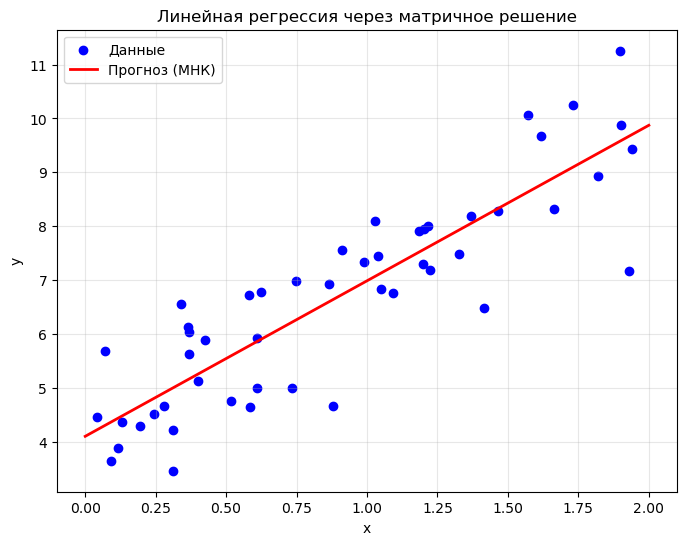

In [21]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 50
x = 2 * np.random.rand(n_samples, 1)
y = 4 + 3 * x + np.random.randn(n_samples, 1)


X_b = np.c_[np.ones((n_samples, 1)), x] 

w_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Параметры модели (нормальное уравнение):")
print(f"w0 (intercept): {w_best[0][0]:.4f}")
print(f"w1 (slope):     {w_best[1][0]:.4f}")


plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Данные')


x_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), x_new]
y_predict = X_new_b.dot(w_best)

plt.plot(x_new, y_predict, "r-", linewidth=2, label="Прогноз (МНК)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Линейная регрессия через матричное решение")
plt.grid(True, alpha=0.3)
plt.show()

### 5. Даны логиты для n классов, найдите:
- Вероятности Softmax;
- Класс с максимальной вероятностью;
- Энтропию распределения.

In [23]:
def analyze_logits(logits):
    exps = np.exp(logits - np.max(logits))
    probabilities = exps / np.sum(exps)

    predicted_class = np.argmax(probabilities)
    
    entropy = -np.sum(probabilities * np.log(probabilities + 1e-15))
    
    return probabilities, predicted_class, entropy

logits = np.array([2.0, 1.0, 0.1, 0.5])
probs, cls, ent = analyze_logits(logits)

print(f"Логиты: {logits}")
print(f"Вероятности Softmax: {probs}")
print(f"Предсказанный класс: {cls}")
print(f"Энтропия: {ent:.4f}")

Логиты: [2.  1.  0.1 0.5]
Вероятности Softmax: [0.57452172 0.21135473 0.08593042 0.12819312]
Предсказанный класс: 0
Энтропия: 1.1211
